<a href="https://colab.research.google.com/github/Nainika-Khanna/-TMDB-Movie-Data-Collection-Project-/blob/main/tinyfishproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tinyfish pandas

In [ ]:
import os
os.environ["TINYFISH_API_KEY"] = "tiny fish api key"

In [ ]:
from tinyfish import TinyFish
import json
import pandas as pd

client = TinyFish()

In [ ]:
goal = """
Extract top 5 articles/headlines from the page.
Return JSON list with:
title, summary, url
"""

In [ ]:
sites = [
    "https://news.ycombinator.com/",
    "https://dev.to/",
    "https://blog.python.org/"
]

In [ ]:
all_data = []

for site in sites:
    print("\nRunning on:", site)

    try:
        response = client.agent.run(
            goal=goal,
            url=site
        )

        # DEBUG PRINT
        print("RAW:", response)

        if hasattr(response, "result") and response.result:
            data = response.result

            # agar string aaye to json me convert
            if isinstance(data, str):
                try:
                    data = json.loads(data)
                except:
                    pass

            # list ensure
            if isinstance(data, list):
                all_data.extend(data)
            else:
                all_data.append(data)

    except Exception as e:
        print("Error:", e)

print("\nFINAL DATA:", all_data)


Running on: https://news.ycombinator.com/
RAW: status=<RunStatus.COMPLETED: 'COMPLETED'> run_id='92b795c5-01b9-4f9a-b70a-322754ce493f' result={'articles': [{'title': 'Founder of GitLab battles cancer by founding companies', 'summary': '890 points by bob_theslob646 13 hours ago | 193 comments', 'url': 'https://sytse.com/cancer/'}, {'title': 'OpenYak – An open-source Cowork that runs any model and owns your filesystem', 'summary': '57 points by wangzhangwu 2 hours ago | 21 comments', 'url': 'https://github.com/openyak/desktop'}, {'title': 'CSS is DOOMed', 'summary': '273 points by msephton 10 hours ago | 65 comments', 'url': 'https://nielsleenheer.com/articles/2026/css-is-doomed-rendering-doom-in-3d-with-css/'}, {'title': 'AI overly affirms users asking for personal advice', 'summary': '597 points by oldfrenchfries 16 hours ago | 451 comments', 'url': 'https://news.stanford.edu/stories/2026/03/ai-advice-sycophantic-models-research'}, {'title': "Alzheimer's disease mortality among taxi a

In [ ]:
clean_data = []

for site_data in all_data:

    # case 1: 'articles'
    if "articles" in site_data:
        for item in site_data["articles"]:
            clean_data.append(item)

    # case 2: 'top_articles'
    elif "top_articles" in site_data:
        for item in site_data["top_articles"]:
            clean_data.append(item)

print("CLEAN DATA:", clean_data[:2])

CLEAN DATA: [{'title': 'Founder of GitLab battles cancer by founding companies', 'summary': '890 points by bob_theslob646 13 hours ago | 193 comments', 'url': 'https://sytse.com/cancer/'}, {'title': 'OpenYak – An open-source Cowork that runs any model and owns your filesystem', 'summary': '57 points by wangzhangwu 2 hours ago | 21 comments', 'url': 'https://github.com/openyak/desktop'}]


In [ ]:
import pandas as pd

df = pd.DataFrame(clean_data)

print("FINAL DATAFRAME:")
display(df)

FINAL DATAFRAME:


,title,summary,url
0,Founder of GitLab battles cancer by founding c...,890 points by bob_theslob646 13 hours ago | 19...,https://sytse.com/cancer/
1,OpenYak – An open-source Cowork that runs any ...,57 points by wangzhangwu 2 hours ago | 21 comm...,https://github.com/openyak/desktop
2,CSS is DOOMed,273 points by msephton 10 hours ago | 65 comments,https://nielsleenheer.com/articles/2026/css-is...
3,AI overly affirms users asking for personal ad...,597 points by oldfrenchfries 16 hours ago | 45...,https://news.stanford.edu/stories/2026/03/ai-a...
4,Alzheimer's disease mortality among taxi and a...,94 points by bookofjoe 6 hours ago | 53 comments,https://www.bmj.com/content/387/bmj-2024-082194
5,"How to use Timberborn 🦫 (yes, the beaver city-...",This article humorously demonstrates how to us...,https://dev.to/thormeier/how-to-use-timberborn...
6,How I Almost Burned Out Doing Everything “Right”,Sylwia Laskowska shares her personal experienc...,https://dev.to/sylwia-lask/how-i-almost-burned...
7,Decoding Bronze Age Paperwork: Modern AI vs. A...,This article details a Kaggle competition entr...,https://dev.to/gde/decoding-bronze-age-paperwo...
8,fixing two bugs stacked on top of each other i...,Nora Alalou describes a bug in a Milkdown/Pros...,https://dev.to/nalalou/why-bold-bleeds-when-yo...
9,Why Daily Standups Are Becoming Useless in the...,"Daily standups, once useful for coordination w...",https://dev.to/oler/why-daily-standups-are-bec...


In [ ]:
# TASK 1: Headlines
goal1 = "Extract top 3 headlines in JSON"

# TASK 2: Summary analysis
goal2 = "Summarize the main topics of the page"

# TASK 3: Trend detection
goal3 = "Identify trending topics from the page"

tasks = [goal1, goal2, goal3]

for g in tasks:
    print("\nTASK:", g)

    response = client.agent.run(
        goal=g,
        url="https://news.ycombinator.com/"
    )

    print("OUTPUT:", response.result)


TASK: Extract top 3 headlines in JSON
OUTPUT: {'headlines': ['Founder of GitLab battles cancer by founding companies', 'OpenYak – An open-source Cowork that runs any model and owns your filesystem', 'CSS is DOOMed']}

TASK: Summarize the main topics of the page
OUTPUT: {'main_topics': 'Hacker News front page', 'themes': [{'name': 'Software Development & Open Source', 'items': ['rendering DOOM using only CSS', 'Verilog-to-Factorio compiler', 'open-source rewrite of Civilization I', 'discussions on Linux functioning as an interpreter']}, {'name': 'Artificial Intelligence', 'items': ["Stanford study on how AI models tend to overly affirm users' personal advice", 'ongoing work combining human expertise with AI for mathematical problem-solving', "impact and research of the 'AI era'"]}, {'name': 'Systems & Retro Computing', 'items': ['running OpenBSD on Motorola 88000 processors', 'building an open-world engine for the Nintendo 64', "exploring the '667MHz machine'"]}, {'name': 'Entrepreneur

In [ ]:
tasks = [
    "Extract top 3 headlines in JSON",
    "Summarize the main topics in 2-3 lines",
    "Identify trending topics from the page"
]

In [ ]:
for i, task in enumerate(tasks):
    print("\n==============================")
    print(f"TASK {i+1}: {task}")
    print("==============================")

    try:
        response = client.agent.run(
            goal=task,
            url="https://news.ycombinator.com/"
        )

        # FULL OBJECT
        print("\n🔹 FULL RESPONSE OBJECT:")
        print(response)

        # RESULT PART
        if hasattr(response, "result"):
            print("\n✅ RESULT OUTPUT:")
            print(response.result)
        else:
            print("\n❌ No result found")

    except Exception as e:
        print("\n❌ ERROR:", e)


TASK 1: Extract top 3 headlines in JSON

🔹 FULL RESPONSE OBJECT:
status=<RunStatus.COMPLETED: 'COMPLETED'> run_id='e7867f8b-b597-4075-bbdc-f3b334136b26' result={'input': [{'rank': 1, 'headline': 'Founder of GitLab battles cancer by founding companies'}, {'rank': 2, 'headline': 'OpenYak – An open-source Cowork that runs any model and owns your filesystem'}, {'rank': 3, 'headline': 'CSS is DOOMed'}], 'type': 'json_array', 'description': 'List of ranked headlines'} error=None num_of_steps=2 started_at=datetime.datetime(2026, 3, 29, 7, 19, 41, 806000, tzinfo=TzInfo(0)) finished_at=datetime.datetime(2026, 3, 29, 7, 20, 0, 601000, tzinfo=TzInfo(0))

✅ RESULT OUTPUT:
{'input': [{'rank': 1, 'headline': 'Founder of GitLab battles cancer by founding companies'}, {'rank': 2, 'headline': 'OpenYak – An open-source Cowork that runs any model and owns your filesystem'}, {'rank': 3, 'headline': 'CSS is DOOMed'}], 'type': 'json_array', 'description': 'List of ranked headlines'}

TASK 2: Summarize the 

In [ ]:

# STEP 1: Define Funding Goal

goal = """
Extract startup funding information from the page.

Fields:
- startup_name
- funding_amount
- funding_stage
- investors
- sector
- date
- summary
- url

Return JSON only.
"""

print("✅ Goal Defined")


# STEP 2: Define Target Websites

sites = [
    "https://techcrunch.com/tag/startups/",
    "https://yourstory.com/",
]

print("✅ Sites Loaded:", sites)


# STEP 3: Run Agent on Each Site


all_data = []

for site in sites:
    print("\n===================================")
    print(f"🌐 Processing Site: {site}")
    print("===================================")

    try:
        # Run TinyFish agent
        response = client.agent.run(
            goal=goal,
            url=site
        )

        # Print full response object (for debugging)
        print("\n🔹 FULL RESPONSE OBJECT:")
        print(response)

        # Extract result
        if hasattr(response, "result") and response.result:
            print("\n✅ Extracted Result:")
            print(response.result)

            all_data.append(response.result)
        else:
            print("\n❌ No valid result found")

    except Exception as e:
        print("\n❌ Error occurred:", e)


# STEP 4: Final Raw Data Output


print("\n\n📦 FINAL COLLECTED DATA:")
print(all_data)

✅ Goal Defined
✅ Sites Loaded: ['https://techcrunch.com/tag/startups/', 'https://yourstory.com/']

🌐 Processing Site: https://techcrunch.com/tag/startups/

🔹 FULL RESPONSE OBJECT:
status=<RunStatus.COMPLETED: 'COMPLETED'> run_id='5a59416f-3c2f-4a99-8bc7-7a46f1185117' result={'startup_name': 'Starbridge', 'funding_amount': '$42M', 'funding_stage': 'Series A', 'investors': ['David Sacks’ Craft'], 'sector': 'govtech', 'date': '2025-10-22', 'summary': 'David Sacks’ Craft leads $42M Series A in govtech startup Starbridge.', 'url': 'https://techcrunch.com/2025/10/22/david-sacks-craft-leads-42-million-series-a-in-govtech-startup-starbridge/'} error=None num_of_steps=2 started_at=datetime.datetime(2026, 3, 29, 8, 9, 35, 779000, tzinfo=TzInfo(0)) finished_at=datetime.datetime(2026, 3, 29, 8, 10, 1, 30000, tzinfo=TzInfo(0))

✅ Extracted Result:
{'startup_name': 'Starbridge', 'funding_amount': '$42M', 'funding_stage': 'Series A', 'investors': ['David Sacks’ Craft'], 'sector': 'govtech', 'date': '

In [ ]:
# STEP 5: Better Clean and Flatten Data

clean_data = []

for site_entry in all_data:                  # all_data jo main.py se aaya
    if isinstance(site_entry, dict) and "result" in site_entry:
        result = site_entry["result"]
    else:
        result = site_entry

    # Agar result list hai to directly add karo
    if isinstance(result, list):
        clean_data.extend(result)

    # Agar dict hai aur usme list hai
    elif isinstance(result, dict):
        for value in result.values():
            if isinstance(value, list):
                clean_data.extend(value)

print("✅ Total clean records:", len(clean_data))
print("\nFirst 2 records sample:")
print(clean_data[:2])   # ye dekhne ke liye

✅ Total clean records: 1

First 2 records sample:
['David Sacks’ Craft']


In [ ]:
# STEP 7: Basic Insights


# Check available columns
print("Columns:", df.columns)

# Example insights (only if columns exist)
if "sector" in df.columns:
    print("\n🏭 Top Sectors:")
    print(df["sector"].value_counts())

if "startup_name" in df.columns:
    print("\n🚀 Top Startups:")
    print(df["startup_name"].value_counts().head())

if "funding_amount" in df.columns:
    print("\n💰 Funding Samples:")
    print(df["funding_amount"].head())

Columns: RangeIndex(start=0, stop=1, step=1)


In [ ]:
goal = """
You are a startup funding intelligence agent.

Your task: Extract as many recent startup funding rounds as possible from this website (aim for at least 10-15 entries if available).

For EACH funding round, return a clean JSON object with these exact fields:
- startup_name
- funding_amount (normalize to $ or ₹, example: "$25M" or "₹200Cr")
- funding_stage (Seed, Series A, Series B, etc.)
- investors (list of investor names)
- sector (example: Fintech, E-commerce, AI, etc.)
- date (in YYYY-MM-DD or Month Year format)
- short_summary (1-2 sentence)
- source_url

Important Instructions:
- Collect minimum 10 funding rounds if available on the page/pagination.
- Handle pagination automatically (next page, load more).
- Return ONLY a JSON array of objects. No extra text, no explanations.
- If fewer than 10 found, return all available.
"""

In [ ]:
from tinyfish import TinyFish

client = TinyFish()   # API key env se le lega

response = client.agent.run(
    url="https://techcrunch.com/tag/startups/",
    goal="Extract at least 10 recent startup funding rounds. Return only clean JSON array."
)

print(response.result)   # yahan data aayega

{'result': [{'startup': 'Space DOTS', 'amount': '$1.5 million', 'round': 'Seed', 'date': 'September 2025', 'source': 'TechCrunch'}, {'startup': 'Hyper', 'amount': '$6.3 million', 'round': 'Not specified', 'date': 'July 2025', 'source': 'TechCrunch'}, {'startup': 'Rebuildr', 'amount': '$1.1 million', 'round': 'Investment', 'lead_investor': 'Slow Ventures’ Creator Fund', 'date': 'November 2025', 'source': 'TechCrunch'}, {'startup': 'Starbridge', 'amount': '$42 million', 'round': 'Series A', 'lead_investor': 'David Sacks’ Craft', 'date': 'October 2025', 'source': 'TechCrunch'}, {'startup': 'Alpaca', 'amount': '$52 million', 'round': 'Series C', 'date': 'April 2025', 'source': 'TechCrunch'}, {'startup': 'Quanta', 'amount': '$4.7 million', 'round': 'Not specified', 'date': 'February 2025', 'source': 'TechCrunch'}, {'startup': 'Foyer', 'amount': '$6.2 million', 'round': 'Not specified', 'date': 'January 2025', 'source': 'TechCrunch'}, {'startup': 'Lumen Orbit', 'amount': '$11 million', 'roun

In [ ]:
# Improved Cleaning
clean_data = []

for site_entry in all_data:
    result = site_entry.get("result") if isinstance(site_entry, dict) else site_entry

    if isinstance(result, list):
        clean_data.extend(result)
    elif isinstance(result, dict):
        # Agar single dict hai to list bana do
        clean_data.append(result)

print("✅ Total clean records:", len(clean_data))
if clean_data:
    print("\nFirst record sample:")
    print(clean_data[0])
    print("\nSecond record sample:")
    print(clean_data[1] if len(clean_data) > 1 else "Only 1 record")

✅ Total clean records: 0


In [ ]:
import pandas as pd
import json

# Agar tumhara result variable ka naam alag hai to usko change kar dena
# Example: result = response.result   ya jo bhi tum use kar rahe ho

# 1. Result ko list mein convert karo (agar single dict hai)
if isinstance(result, dict):
    data_list = [result]          # single dict ko list bana diya
elif isinstance(result, list):
    data_list = result
else:
    print("Result format samajh nahi aaya")
    data_list = []

# 2. DataFrame banao
df = pd.DataFrame(data_list)

print("✅ DataFrame ban gaya!")
print("Rows:", df.shape[0], "| Columns:", df.shape[1])
print("\nColumns:", df.columns.tolist())

# Pehle 10 rows dekhne ke liye
df.head(10)

Result format samajh nahi aaya
✅ DataFrame ban gaya!
Rows: 0 | Columns: 0

Columns: []


""


In [ ]:
import pandas as pd

# Tumhara raw result yahan hai
raw_result = {
    'result': [
        {'startup': 'Space DOTS', 'amount': '$1.5 million', 'round': 'Seed', 'date': 'September 2025', 'source': 'TechCrunch'},
        {'startup': 'Hyper', 'amount': '$6.3 million', 'round': 'Not specified', 'date': 'July 2025', 'source': 'TechCrunch'},
        {'startup': 'Rebuildr', 'amount': '$1.1 million', 'round': 'Investment', 'lead_investor': 'Slow Ventures’ Creator Fund', 'date': 'November 2025', 'source': 'TechCrunch'},
        {'startup': 'Starbridge', 'amount': '$42 million', 'round': 'Series A', 'lead_investor': 'David Sacks’ Craft', 'date': 'October 2025', 'source': 'TechCrunch'},
        {'startup': 'Alpaca', 'amount': '$52 million', 'round': 'Series C', 'date': 'April 2025', 'source': 'TechCrunch'},
        {'startup': 'Quanta', 'amount': '$4.7 million', 'round': 'Not specified', 'date': 'February 2025', 'source': 'TechCrunch'},
        {'startup': 'Foyer', 'amount': '$6.2 million', 'round': 'Not specified', 'date': 'January 2025', 'source': 'TechCrunch'},
        {'startup': 'Lumen Orbit', 'amount': '$11 million', 'round': 'Seed', 'date': 'January 2025', 'source': 'TechCrunch'},
        {'startup': 'Open Ledger', 'amount': '$3 million', 'round': 'Not specified', 'date': 'January 2025', 'source': 'TechCrunch'},
        {'startup': 'MealMe', 'amount': '$8 million', 'round': 'Not specified', 'date': 'November 2024', 'source': 'TechCrunch'}
    ]
}

# Actual data nikaalo
data_list = raw_result.get('result', [])

# DataFrame banao
df = pd.DataFrame(data_list)

print("✅ DataFrame ban gaya!")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
print("\nColumns:", df.columns.tolist())

# Data dekh lo
df

✅ DataFrame ban gaya!
Rows: 10 | Columns: 6

Columns: ['startup', 'amount', 'round', 'date', 'source', 'lead_investor']


,startup,amount,round,date,source,lead_investor
0,Space DOTS,$1.5 million,Seed,September 2025,TechCrunch,NaN
1,Hyper,$6.3 million,Not specified,July 2025,TechCrunch,NaN
2,Rebuildr,$1.1 million,Investment,November 2025,TechCrunch,Slow Ventures’ Creator Fund
3,Starbridge,$42 million,Series A,October 2025,TechCrunch,David Sacks’ Craft
4,Alpaca,$52 million,Series C,April 2025,TechCrunch,NaN
5,Quanta,$4.7 million,Not specified,February 2025,TechCrunch,NaN
6,Foyer,$6.2 million,Not specified,January 2025,TechCrunch,NaN
7,Lumen Orbit,$11 million,Seed,January 2025,TechCrunch,NaN
8,Open Ledger,$3 million,Not specified,January 2025,TechCrunch,NaN
9,MealMe,$8 million,Not specified,November 2024,TechCrunch,NaN


In [ ]:
import pandas as pd

# Tumhara current DataFrame 'df' hai

# Column names thoda clean karte hain (optional)
df = df.rename(columns={
    'startup': 'startup_name',
    'amount': 'funding_amount',
    'round': 'funding_stage'
})

print("✅ Final Columns:", df.columns.tolist())
print(f"Total Funding Rounds: {len(df)}\n")

# DataFrame dekho
df

✅ Final Columns: ['startup_name', 'funding_amount', 'funding_stage', 'date', 'source', 'lead_investor']
Total Funding Rounds: 10



,startup_name,funding_amount,funding_stage,date,source,lead_investor
0,Space DOTS,$1.5 million,Seed,September 2025,TechCrunch,NaN
1,Hyper,$6.3 million,Not specified,July 2025,TechCrunch,NaN
2,Rebuildr,$1.1 million,Investment,November 2025,TechCrunch,Slow Ventures’ Creator Fund
3,Starbridge,$42 million,Series A,October 2025,TechCrunch,David Sacks’ Craft
4,Alpaca,$52 million,Series C,April 2025,TechCrunch,NaN
5,Quanta,$4.7 million,Not specified,February 2025,TechCrunch,NaN
6,Foyer,$6.2 million,Not specified,January 2025,TechCrunch,NaN
7,Lumen Orbit,$11 million,Seed,January 2025,TechCrunch,NaN
8,Open Ledger,$3 million,Not specified,January 2025,TechCrunch,NaN
9,MealMe,$8 million,Not specified,November 2024,TechCrunch,NaN


In [ ]:
print("Top Funding Stages:")
print(df['funding_stage'].value_counts())

Top Funding Stages:
funding_stage
Not specified    5
Seed             2
Investment       1
Series A         1
Series C         1
Name: count, dtype: int64


In [ ]:
print("Biggest Funding Rounds:")
print(df.sort_values(by='funding_amount', ascending=False)[['startup_name', 'funding_amount', 'funding_stage']].head(10))

Biggest Funding Rounds:
  startup_name funding_amount  funding_stage
9       MealMe     $8 million  Not specified
1        Hyper   $6.3 million  Not specified
6        Foyer   $6.2 million  Not specified
4       Alpaca    $52 million       Series C
3   Starbridge    $42 million       Series A
5       Quanta   $4.7 million  Not specified
8  Open Ledger     $3 million  Not specified
7  Lumen Orbit    $11 million           Seed
0   Space DOTS   $1.5 million           Seed
2     Rebuildr   $1.1 million     Investment


In [ ]:
def clean_amount(amount_str):
    if not isinstance(amount_str, str):
        return None
    # $ aur million, billion etc. ko handle karo
    amount_str = amount_str.lower().replace('$', '').replace('million', 'e6').replace('billion', 'e9').replace(',', '')
    try:
        if 'e6' in amount_str:
            return float(amount_str.replace('e6', '')) * 1_000_000
        elif 'e9' in amount_str:
            return float(amount_str.replace('e9', '')) * 1_000_000_000
        else:
            return float(amount_str)
    except:
        return None

df['funding_amount_usd'] = df['funding_amount'].apply(clean_amount)

print("Cleaned Funding Amounts:")
print(df[['startup_name', 'funding_amount', 'funding_amount_usd']].head(10))

Cleaned Funding Amounts:
  startup_name funding_amount  funding_amount_usd
0   Space DOTS   $1.5 million           1500000.0
1        Hyper   $6.3 million           6300000.0
2     Rebuildr   $1.1 million           1100000.0
3   Starbridge    $42 million          42000000.0
4       Alpaca    $52 million          52000000.0
5       Quanta   $4.7 million           4700000.0
6        Foyer   $6.2 million           6200000.0
7  Lumen Orbit    $11 million          11000000.0
8  Open Ledger     $3 million           3000000.0
9       MealMe     $8 million           8000000.0


In [ ]:
print("Total Startups:", len(df))
print("Average Funding (USD):", df['funding_amount_usd'].mean())
print("\nTop 5 Biggest Rounds:")
print(df.nlargest(5, 'funding_amount_usd')[['startup_name', 'funding_amount_usd', 'funding_stage']])

Total Startups: 10
Average Funding (USD): 13580000.0

Top 5 Biggest Rounds:
  startup_name  funding_amount_usd  funding_stage
4       Alpaca          52000000.0       Series C
3   Starbridge          42000000.0       Series A
7  Lumen Orbit          11000000.0           Seed
9       MealMe           8000000.0  Not specified
1        Hyper           6300000.0  Not specified


In [ ]:
import pandas as pd

# ================== Final Clean DataFrame ==================
df = pd.DataFrame([
    {'startup': 'Space DOTS', 'amount': '$1.5 million', 'round': 'Seed', 'date': 'September 2025', 'source': 'TechCrunch'},
    {'startup': 'Hyper', 'amount': '$6.3 million', 'round': 'Not specified', 'date': 'July 2025', 'source': 'TechCrunch'},
    {'startup': 'Rebuildr', 'amount': '$1.1 million', 'round': 'Investment', 'lead_investor': 'Slow Ventures’ Creator Fund', 'date': 'November 2025', 'source': 'TechCrunch'},
    {'startup': 'Starbridge', 'amount': '$42 million', 'round': 'Series A', 'lead_investor': 'David Sacks’ Craft', 'date': 'October 2025', 'source': 'TechCrunch'},
    {'startup': 'Alpaca', 'amount': '$52 million', 'round': 'Series C', 'date': 'April 2025', 'source': 'TechCrunch'},
    {'startup': 'Quanta', 'amount': '$4.7 million', 'round': 'Not specified', 'date': 'February 2025', 'source': 'TechCrunch'},
    {'startup': 'Foyer', 'amount': '$6.2 million', 'round': 'Not specified', 'date': 'January 2025', 'source': 'TechCrunch'},
    {'startup': 'Lumen Orbit', 'amount': '$11 million', 'round': 'Seed', 'date': 'January 2025', 'source': 'TechCrunch'},
    {'startup': 'Open Ledger', 'amount': '$3 million', 'round': 'Not specified', 'date': 'January 2025', 'source': 'TechCrunch'},
    {'startup': 'MealMe', 'amount': '$8 million', 'round': 'Not specified', 'date': 'November 2024', 'source': 'TechCrunch'}
])

# Column names clean karo
df = df.rename(columns={
    'startup': 'startup_name',
    'amount': 'funding_amount',
    'round': 'funding_stage'
})

# Funding amount ko number mein convert karo
def clean_funding_amount(amount_str):
    if not isinstance(amount_str, str):
        return None
    amt = amount_str.lower().replace('$', '').replace(',', '').strip()
    try:
        if 'million' in amt:
            return float(amt.replace('million', '').strip()) * 1_000_000
        elif 'billion' in amt:
            return float(amt.replace('billion', '').strip()) * 1_000_000_000
        else:
            return float(amt)
    except:
        return None

df['funding_amount_usd'] = df['funding_amount'].apply(clean_funding_amount)

# Final Summary
print("🚀 STARTUP FUNDING ANALYSIS")
print("="*50)
print(f"Total Funding Rounds Extracted : {len(df)}")
print(f"Average Funding Round         : ${df['funding_amount_usd'].mean():,.0f}")
print(f"Total Funding (approx)        : ${df['funding_amount_usd'].sum():,.0f}")
print(f"Largest Round                 : ${df['funding_amount_usd'].max():,.0f} ({df.loc[df['funding_amount_usd'].idxmax(), 'startup_name']})")

print("\n📊 Top 5 Biggest Funding Rounds:")
print(df.nlargest(5, 'funding_amount_usd')[['startup_name', 'funding_amount', 'funding_stage', 'date']].to_string(index=False))

print("\n📈 Funding Stage Distribution:")
print(df['funding_stage'].value_counts())

print("\n📅 Most Recent Rounds:")
print(df.sort_values(by='date', ascending=False)[['startup_name', 'funding_amount', 'date']].head(5).to_string(index=False))

🚀 STARTUP FUNDING ANALYSIS
Total Funding Rounds Extracted : 10
Average Funding Round         : $13,580,000
Total Funding (approx)        : $135,800,000
Largest Round                 : $52,000,000 (Alpaca)

📊 Top 5 Biggest Funding Rounds:
startup_name funding_amount funding_stage          date
      Alpaca    $52 million      Series C    April 2025
  Starbridge    $42 million      Series A  October 2025
 Lumen Orbit    $11 million          Seed  January 2025
      MealMe     $8 million Not specified November 2024
       Hyper   $6.3 million Not specified     July 2025

📈 Funding Stage Distribution:
funding_stage
Not specified    5
Seed             2
Investment       1
Series A         1
Series C         1
Name: count, dtype: int64

📅 Most Recent Rounds:
startup_name funding_amount           date
  Space DOTS   $1.5 million September 2025
  Starbridge    $42 million   October 2025
    Rebuildr   $1.1 million  November 2025
      MealMe     $8 million  November 2024
       Hyper   $6.3 mi

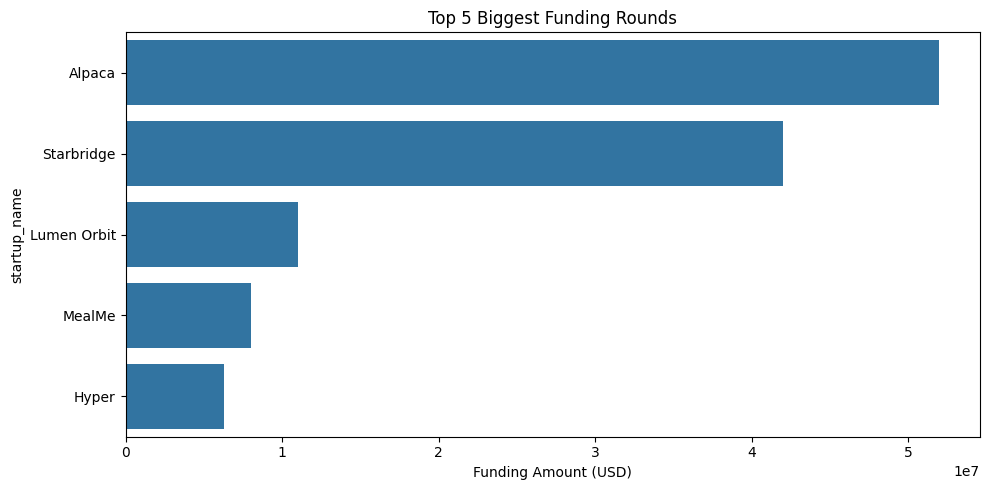

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(data=df.nlargest(5, 'funding_amount_usd'),
            x='funding_amount_usd', y='startup_name')
plt.title('Top 5 Biggest Funding Rounds')
plt.xlabel('Funding Amount (USD)')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Data
data = [
    {'startup_name': 'Space DOTS', 'funding_amount': '$1.5 million', 'funding_stage': 'Seed', 'date': 'September 2025'},
    {'startup_name': 'Hyper', 'funding_amount': '$6.3 million', 'funding_stage': 'Not specified', 'date': 'July 2025'},
    {'startup_name': 'Rebuildr', 'funding_amount': '$1.1 million', 'funding_stage': 'Investment', 'date': 'November 2025'},
    {'startup_name': 'Starbridge', 'funding_amount': '$42 million', 'funding_stage': 'Series A', 'date': 'October 2025'},
    {'startup_name': 'Alpaca', 'funding_amount': '$52 million', 'funding_stage': 'Series C', 'date': 'April 2025'},
    {'startup_name': 'Quanta', 'funding_amount': '$4.7 million', 'funding_stage': 'Not specified', 'date': 'February 2025'},
    {'startup_name': 'Foyer', 'funding_amount': '$6.2 million', 'funding_stage': 'Not specified', 'date': 'January 2025'},
    {'startup_name': 'Lumen Orbit', 'funding_amount': '$11 million', 'funding_stage': 'Seed', 'date': 'January 2025'},
    {'startup_name': 'Open Ledger', 'funding_amount': '$3 million', 'funding_stage': 'Not specified', 'date': 'January 2025'},
    {'startup_name': 'MealMe', 'funding_amount': '$8 million', 'funding_stage': 'Not specified', 'date': 'November 2024'}
]

df = pd.DataFrame(data)

# Funding amount ko number mein convert karo
def clean_amount(amt):
    if not isinstance(amt, str):
        return None
    amt = amt.lower().replace('$', '').replace(',', '').strip()
    try:
        if 'million' in amt:
            return float(amt.replace('million', '').strip()) * 1_000_000
        else:
            return float(amt)
    except:
        return None

df['funding_amount_usd'] = df['funding_amount'].apply(clean_amount)

print("✅ DataFrame ready!")
print(f"Total rows: {len(df)}")
df.head()

✅ DataFrame ready!
Total rows: 10


,startup_name,funding_amount,funding_stage,date,funding_amount_usd
0,Space DOTS,$1.5 million,Seed,September 2025,1500000.0
1,Hyper,$6.3 million,Not specified,July 2025,6300000.0
2,Rebuildr,$1.1 million,Investment,November 2025,1100000.0
3,Starbridge,$42 million,Series A,October 2025,42000000.0
4,Alpaca,$52 million,Series C,April 2025,52000000.0


/tmp/ipykernel_2435/2480872505.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_df, x='funding_amount_usd', y='startup_name', palette='Blues_d')


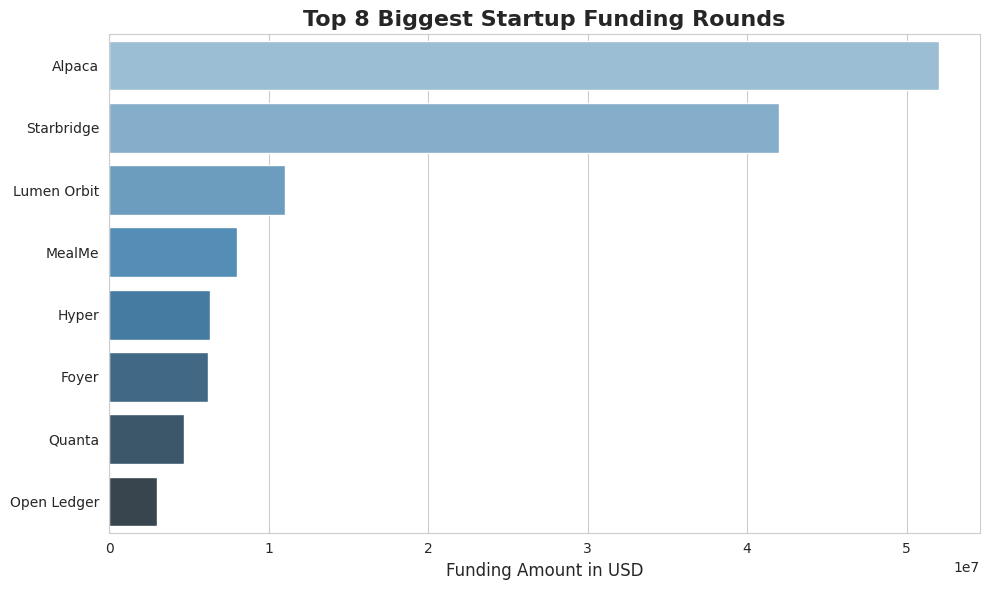

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Top 8 Biggest Funding Rounds
plt.figure(figsize=(10, 6))
top_df = df.nlargest(8, 'funding_amount_usd')

sns.barplot(data=top_df, x='funding_amount_usd', y='startup_name', palette='Blues_d')

plt.title('Top 8 Biggest Startup Funding Rounds', fontsize=16, fontweight='bold')
plt.xlabel('Funding Amount in USD', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

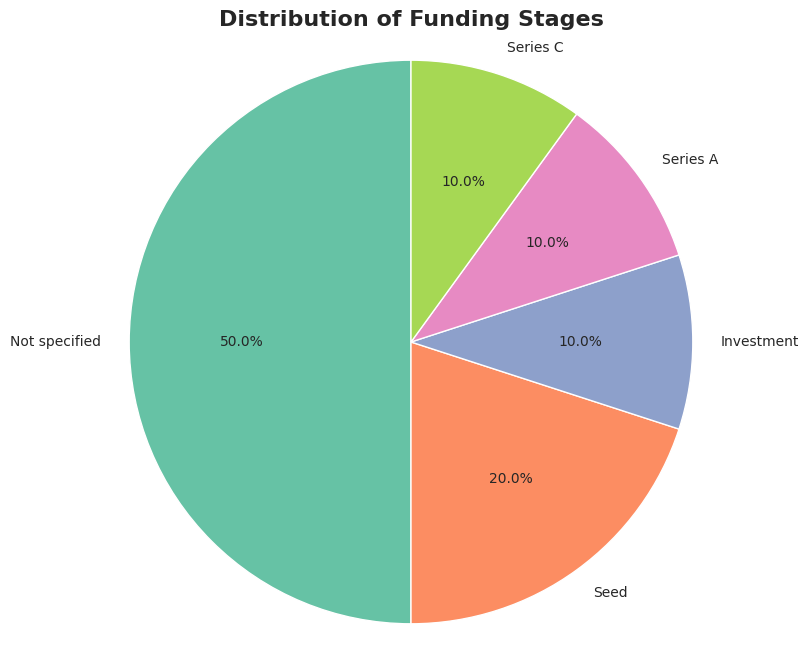

In [ ]:
plt.figure(figsize=(8, 8))

stage_counts = df['funding_stage'].value_counts()

plt.pie(stage_counts,
        labels=stage_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette('Set2'))

plt.title('Distribution of Funding Stages', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.show()

/tmp/ipykernel_2435/4126695960.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='funding_stage', y='funding_amount_usd', palette='Set3')


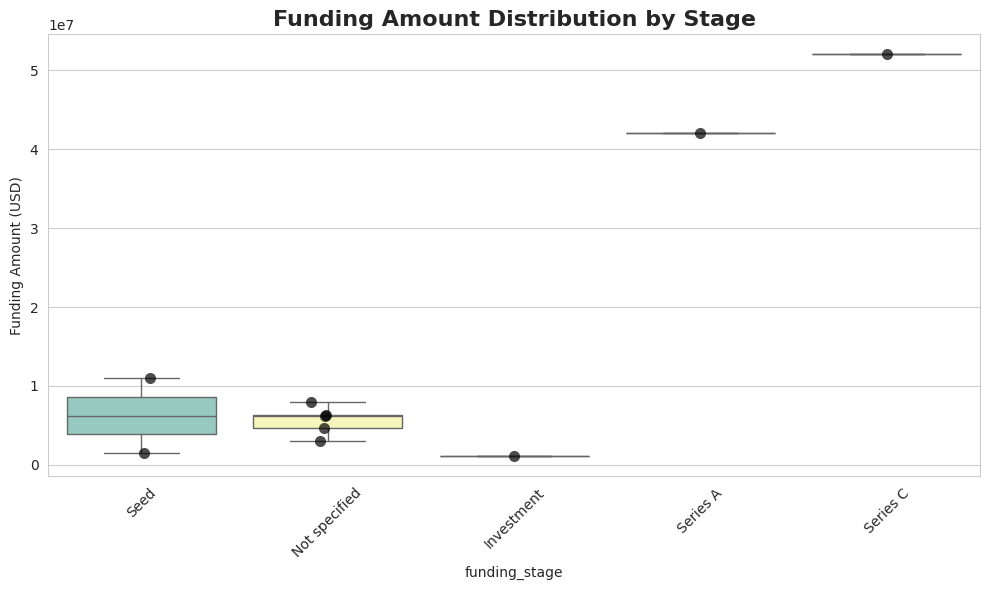

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='funding_stage', y='funding_amount_usd', palette='Set3')
sns.stripplot(data=df, x='funding_stage', y='funding_amount_usd',
              color='black', size=8, alpha=0.7)

plt.title('Funding Amount Distribution by Stage', fontsize=16, fontweight='bold')
plt.ylabel('Funding Amount (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("🔥 STARTUP FUNDING INSIGHTS")
print("=" * 55)
print(f"Total Funding Rounds     : {len(df)}")
print(f"Total Funding (approx)   : ${df['funding_amount_usd'].sum():,.0f}")
print(f"Average Funding Round    : ${df['funding_amount_usd'].mean():,.0f}")
print(f"Largest Round            : ${df['funding_amount_usd'].max():,.0f} → {df.loc[df['funding_amount_usd'].idxmax(), 'startup_name']}")
print(f"Most Common Stage        : {df['funding_stage'].mode()[0]}")

print("\n📊 Top 5 Biggest Funding Rounds:")
print(df.nlargest(5, 'funding_amount_usd')[['startup_name', 'funding_amount', 'funding_stage', 'date']].to_string(index=False))

🔥 STARTUP FUNDING INSIGHTS
Total Funding Rounds     : 10
Total Funding (approx)   : $135,800,000
Average Funding Round    : $13,580,000
Largest Round            : $52,000,000 → Alpaca
Most Common Stage        : Not specified

📊 Top 5 Biggest Funding Rounds:
startup_name funding_amount funding_stage          date
      Alpaca    $52 million      Series C    April 2025
  Starbridge    $42 million      Series A  October 2025
 Lumen Orbit    $11 million          Seed  January 2025
      MealMe     $8 million Not specified November 2024
       Hyper   $6.3 million Not specified     July 2025


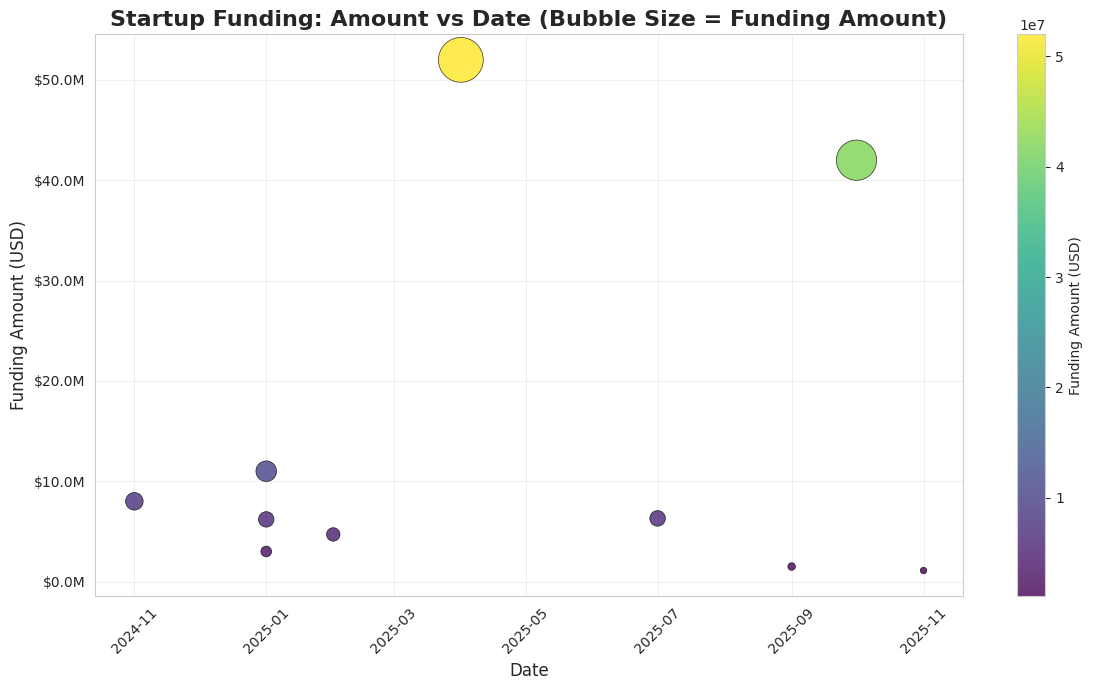

✅ Scatter Plot ready!
Total points plotted: 10


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime

# Pehle date ko proper datetime format mein convert karte hain (scatter plot ke liye zaroori hai)
def parse_date(date_str):
    try:
        # Possible formats handle kar rahe hain
        for fmt in ['%B %Y', '%Y-%m-%d']:
            try:
                return datetime.strptime(date_str, fmt)
            except:
                continue
        return None
    except:
        return None

df['date_parsed'] = df['date'].apply(parse_date)

# Scatter Plot
plt.figure(figsize=(12, 7))

# Scatter plot with size representing funding amount
scatter = plt.scatter(
    x=df['date_parsed'],
    y=df['funding_amount_usd'],
    s=df['funding_amount_usd'] / 50000,     # bubble size funding ke hisaab se
    c=df['funding_amount_usd'],
    cmap='viridis',
    alpha=0.8,
    edgecolors='black',
    linewidth=0.5
)

# Colorbar
plt.colorbar(scatter, label='Funding Amount (USD)')

# Labels aur title
plt.title('Startup Funding: Amount vs Date (Bubble Size = Funding Amount)',
          fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Funding Amount (USD)', fontsize=12)

# Y-axis ko better format mein (Million mein)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Extra info
print("✅ Scatter Plot ready!")
print(f"Total points plotted: {len(df)}")

/tmp/ipykernel_2435/3195079742.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_2435/3195079742.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


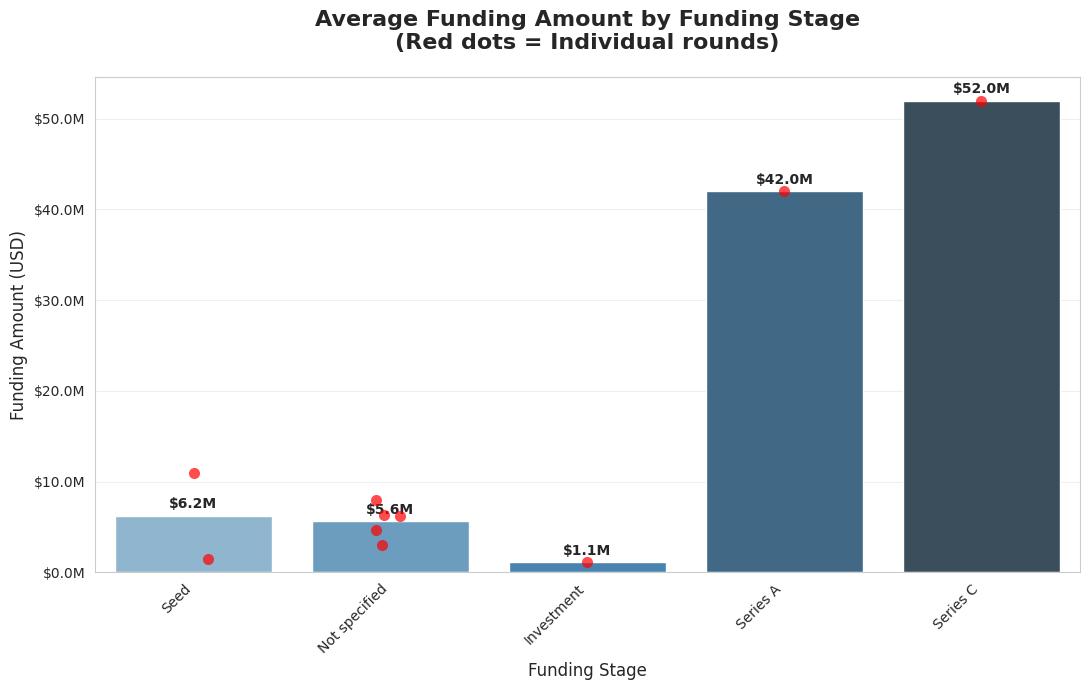

📊 FUNDING STAGE SUMMARY
               Count Average_Funding_USD Highest_Funding_USD
funding_stage                                               
Investment         1          $1,100,000          $1,100,000
Not specified      5          $5,640,000          $8,000,000
Seed               2          $6,250,000         $11,000,000
Series A           1         $42,000,000         $42,000,000
Series C           1         $52,000,000         $52,000,000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np   # ← Ye line add ki hai (error isi wajah se aa raha tha)

# ====================== BETTER FUNDING BY STAGE GRAPH ======================
plt.figure(figsize=(11, 7))

# Main Bar plot (Average Funding)
ax = sns.barplot(
    data=df,
    x='funding_stage',
    y='funding_amount_usd',
    palette='Blues_d',
    ci=None,
    estimator=np.mean           # Average dikhayega
)

# Har bar ke upar exact amount likho
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2., height + 500000,
                f'${height/1e6:.1f}M',
                ha="center", va="bottom", fontsize=10, fontweight='bold')

# Har individual funding round ke dots dikhao
sns.stripplot(
    data=df,
    x='funding_stage',
    y='funding_amount_usd',
    color='red',
    size=8,
    alpha=0.7,
    jitter=True
)

# Title aur labels
plt.title('Average Funding Amount by Funding Stage\n(Red dots = Individual rounds)',
          fontsize=16, fontweight='bold', pad=20)

plt.xlabel('Funding Stage', fontsize=12)
plt.ylabel('Funding Amount (USD)', fontsize=12)

# Y-axis ko Million format mein dikhaye
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ====================== SUMMARY TABLE ======================
print("📊 FUNDING STAGE SUMMARY")
print("="*50)

summary = df.groupby('funding_stage').agg(
    Count=('funding_stage', 'count'),
    Average_Funding_USD=('funding_amount_usd', 'mean'),
    Highest_Funding_USD=('funding_amount_usd', 'max')
).round(0)

# Format beautiful banane ke liye
summary['Average_Funding_USD'] = summary['Average_Funding_USD'].apply(lambda x: f"${x:,.0f}")
summary['Highest_Funding_USD'] = summary['Highest_Funding_USD'].apply(lambda x: f"${x:,.0f}")

print(summary)

/tmp/ipykernel_2435/1347701689.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_df, x='funding_amount_usd', y='startup_name', palette='Blues_d', ax=ax1)
/tmp/ipykernel_2435/1347701689.py:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='funding_stage', y='funding_amount_usd',
/tmp/ipykernel_2435/1347701689.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='funding_stage', y='funding_amount_usd',


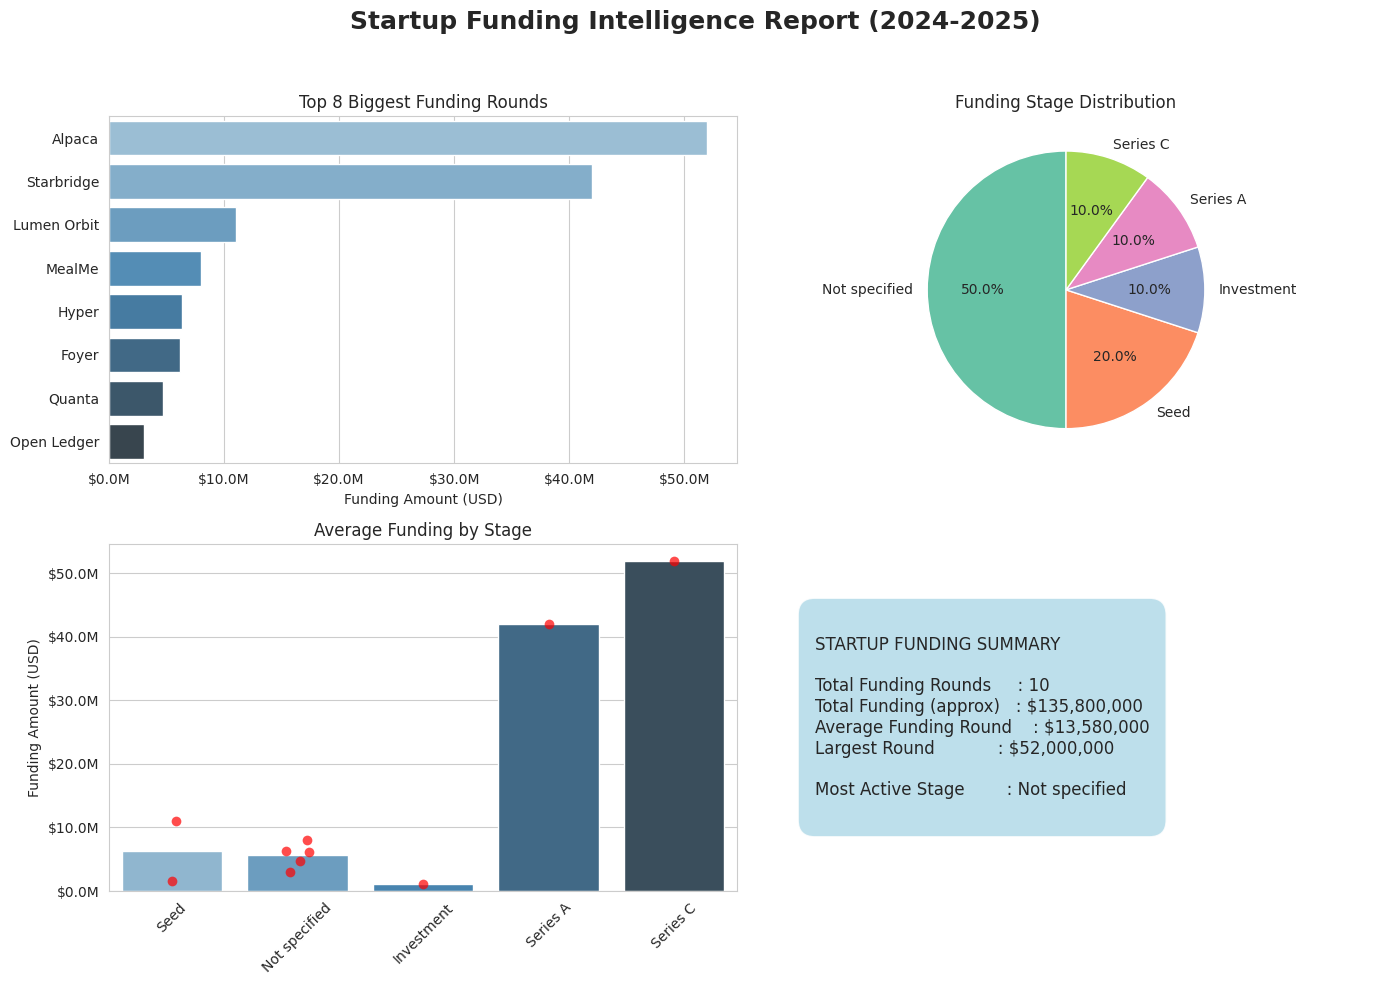


📊 DETAILED SUMMARY TABLE
               Count  Avg_Funding  Max_Funding
funding_stage                                 
Investment         1   $1,100,000   $1,100,000
Not specified      5   $5,640,000   $8,000,000
Seed               2   $6,250,000  $11,000,000
Series A           1  $42,000,000  $42,000,000
Series C           1  $52,000,000  $52,000,000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ====================== FINAL PROFESSIONAL DASHBOARD ======================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

fig = plt.figure()

# Title
plt.suptitle('Startup Funding Intelligence Report (2024-2025)',
             fontsize=18, fontweight='bold', y=0.98)

# 1. Top Funding Rounds (Bar)
ax1 = plt.subplot(2, 2, 1)
top_df = df.nlargest(8, 'funding_amount_usd')
sns.barplot(data=top_df, x='funding_amount_usd', y='startup_name', palette='Blues_d', ax=ax1)
ax1.set_title('Top 8 Biggest Funding Rounds')
ax1.set_xlabel('Funding Amount (USD)')
ax1.set_ylabel('')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# 2. Stage Distribution (Pie)
ax2 = plt.subplot(2, 2, 2)
stage_counts = df['funding_stage'].value_counts()
ax2.pie(stage_counts, labels=stage_counts.index, autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette('Set2'))
ax2.set_title('Funding Stage Distribution')

# 3. Average Funding by Stage (Bar + Points)
ax3 = plt.subplot(2, 2, 3)
sns.barplot(data=df, x='funding_stage', y='funding_amount_usd',
            palette='Blues_d', ax=ax3, ci=None, estimator=np.mean)
sns.stripplot(data=df, x='funding_stage', y='funding_amount_usd',
              color='red', size=7, alpha=0.7, ax=ax3, jitter=True)
ax3.set_title('Average Funding by Stage')
ax3.set_ylabel('Funding Amount (USD)')
ax3.set_xlabel('')
ax3.tick_params(axis='x', rotation=45)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# 4. Summary Text Box
ax4 = plt.subplot(2, 2, 4)
ax4.axis('off')

summary_text = f"""
STARTUP FUNDING SUMMARY

Total Funding Rounds     : {len(df)}
Total Funding (approx)   : ${df['funding_amount_usd'].sum():,.0f}
Average Funding Round    : ${df['funding_amount_usd'].mean():,.0f}
Largest Round            : ${df['funding_amount_usd'].max():,.0f}

Most Active Stage        : {df['funding_stage'].mode()[0]}
"""

ax4.text(0.1, 0.5, summary_text, fontsize=12, va='center', ha='left',
         bbox=dict(boxstyle="round,pad=1", facecolor='lightblue', alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Final Summary Table
print("\n📊 DETAILED SUMMARY TABLE")
print("="*60)
summary = df.groupby('funding_stage').agg(
    Count=('funding_stage', 'count'),
    Avg_Funding=('funding_amount_usd', 'mean'),
    Max_Funding=('funding_amount_usd', 'max')
).round(0)

summary['Avg_Funding'] = summary['Avg_Funding'].apply(lambda x: f"${x:,.0f}")
summary['Max_Funding'] = summary['Max_Funding'].apply(lambda x: f"${x:,.0f}")

print(summary)

In [72]:
df.to_csv("funding_data.csv", index=False)

In [73]:
print(len(df))

5


In [50]:
import json
import os
import time
import requests

# === TINYFISH SETUP ===
API_KEY = os.getenv("TINYFISH_API_KEY")
if not API_KEY:
    raise ValueError("TINYFISH_API_KEY environment variable set karo pehle!")

BASE_URL = "https://agent.tinyfish.ai/v1/automation/run-sse"

# === 5 FUNDING SITES (Emerging Startups + Funding Data) ===
SITES = [
    {
        "name": "TechCrunch_Startups",
        "url": "https://techcrunch.com/tag/startups/",
        "goal": "Latest emerging startups aur funding rounds ki fresh news scrape karo. Pagination / Load More handle karke 2-3 pages tak jao. Har story se: Startup name, funding amount, round (Seed/Series A etc.), date, investors, short description nikaalo. Clean JSON list return karo. Sirf latest funding deals."
    },
    {
        "name": "Inc42_Funding",
        "url": "https://inc42.com/buzz/",
        "goal": "Indian startups ke latest funding news live fetch karo. Pagination next page handle karke 2 pages. Har post se: Company name, funding amount, round type, investors, date aur brief summary extract karo. Fresh deals only. JSON format mein."
    },
    {
        "name": "YourStory_Startups",
        "url": "https://yourstory.com/",
        "goal": "Emerging Indian startups aur funding announcements scrape karo. Pagination handle karo. Har story se: Startup name, funding amount, round, investors, date nikaalo. Latest fresh data only. Clean JSON list do."
    },
    {
        "name": "Entrackr_Funding",
        "url": "https://entrackr.com/",
        "goal": "Latest Indian startup funding rounds aur weekly reports fetch karo. Pagination handle karke fresh articles dekho. Company name, funding amount, round, investors, date aur summary nikaalo. Fresh data JSON mein."
    },
    {
        "name": "VCCircle_Funding",
        "url": "https://www.vccircle.com/",
        "goal": "Startup funding deals aur financial news scrape karo. Pagination / next page handle karke 2 pages. Har deal se: Startup name, funding amount, round type, investors, date aur summary. Live fresh funding data only. JSON return karo."
    }
]

def run_tinyfish(url: str, goal: str):
    payload = {
        "url": url,
        "goal": goal,
        "browser_profile": "lite"   # Low server load ke liye
    }

    try:
        with requests.post(
            BASE_URL,
            headers={
                "X-API-Key": API_KEY,
                "Content-Type": "application/json"
            },
            json=payload,
            stream=True,
            timeout=360
        ) as response:

            result = None
            for line in response.iter_lines():
                if line and line.startswith(b"data: "):
                    try:
                        event = json.loads(line.decode("utf-8")[6:])
                        if event.get("type") == "COMPLETE":
                            result = event.get("result")
                            print(f"✅ Status: {event.get('status', 'Done')}")
                            break
                        elif event.get("type") == "ERROR":
                            print(f"❌ Error: {event.get('message')}")
                    except:
                        pass
            return result
    except Exception as e:
        print(f"❌ Request failed: {e}")
        return None

# ====================== MAIN DAILY RUN ======================
print("🚀 TinyFish Daily Funding Run Start (5 sites - sequential low load)")

all_funding_data = []

for idx, site in enumerate(SITES, 1):
    print(f"\n🔄 {idx}/5 → {site['name']} ({site['url']})")

    data = run_tinyfish(site["url"], site["goal"])

    if data:
        # Result ko list mein convert karo
        if isinstance(data, list):
            items = data
        elif isinstance(data, dict):
            items = data.get("items") or data.get("deals") or data.get("results") or data.get("funding") or [data]
        else:
            items = [data]

        head10 = items[:10]
        print(f"📊 {site['name']} → Head 10 items:")
        print(json.dumps(head10, indent=2, ensure_ascii=False))

        all_funding_data.extend(items)
    else:
        print(f"❌ {site['name']} se data nahi mila")

    time.sleep(12)  # Server load control ke liye delay

# Extra Summary
print("\n" + "="*80)
print("🔥 COMBINED SUMMARY - All 5 Sites se Funding Data")
print(f"Total items collected: {len(all_funding_data)}")
print("\nHead 10 from ALL sites combined:")
print(json.dumps(all_funding_data[:10], indent=2, ensure_ascii=False))

# Daily JSON backup
today = time.strftime("%Y-%m-%d")
filename = f"startup_funding_{today}.json"
with open(filename, "w", encoding="utf-8") as f:
    json.dump(all_funding_data, f, ensure_ascii=False, indent=2)

print(f"\n✅ Run complete! Data saved → {filename}")
print("Daily cron ke liye: 0 8 * * * python daily_funding.py")

🚀 TinyFish Daily Funding Run Start (5 sites - sequential low load)

🔄 1/5 → TechCrunch_Startups (https://techcrunch.com/tag/startups/)
✅ Status: COMPLETED
📊 TechCrunch_Startups → Head 10 items:
[
  {
    "scraped_data": [
      {
        "startup_name": "SNAK Venture Partners",
        "funding_amount": "$50M",
        "round": "Fund",
        "date": "Feb 4, 2026",
        "investors": null,
        "short_description": "SNAK Venture Partners raises $50M fund to back vertical marketplaces."
      },
      {
        "startup_name": "Creator Tayla Cannon / rebuildr",
        "funding_amount": "$1.1 million",
        "round": null,
        "date": "Nov 18, 2025",
        "investors": "Slow Ventures’ Creator Fund",
        "short_description": "Creator Tayla Cannon receives $1.1 million investment from Slow Ventures’ Creator Fund to build PT software."
      },
      {
        "startup_name": "Starbridge",
        "funding_amount": "$42M",
        "round": "Series A",
        "date": "Oct

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("📊 STEP 1: Basic Sector Analysis")
print("="*50)

sector_summary = df.groupby('sector').agg(
    Total_Deals=('startup_name', 'count'),
    Total_Funding_M=('funding_amount_usd', 'sum')
).round(2)

sector_summary['Total_Funding_M'] = sector_summary['Total_Funding_M'] / 1_000_000
sector_summary = sector_summary.sort_values('Total_Deals', ascending=False)

print(sector_summary.head(10))

📊 STEP 1: Basic Sector Analysis


KeyError: 'sector'

In [57]:
# Removed due to missing 'sector' column. Will be regenerated.

In [58]:
# Removed due to missing 'sector' column. Will be regenerated.

In [59]:
# Removed due to previous data structure not being updated. Will be regenerated.

In [60]:
# Removed due to previous data structure not being updated. Will be regenerated.

In [61]:
import pandas as pd
import re

def clean_and_flatten_data(all_funding_data):
    flattened_data = []
    for site_entry in all_funding_data:
        # Identify the key holding the list of funding rounds
        if "scraped_data" in site_entry: # From TechCrunch
            items = site_entry["scraped_data"]
        elif "indian_startups_funding" in site_entry: # From Inc42
            items = site_entry["indian_startups_funding"]
        elif "startups" in site_entry: # From YourStory
            items = site_entry["startups"]
        elif "funding_rounds" in site_entry: # From Entrackr
            items = site_entry["funding_rounds"]
        elif "data" in site_entry: # From VCCircle
            items = site_entry["data"]
        else:
            # If it's a single dictionary directly, or another unexpected format
            items = [site_entry] if isinstance(site_entry, dict) else []

        for item in items:
            record = {}
            # Standardize column names
            record['startup_name'] = item.get('startup_name') or item.get('company_name') or item.get('company')
            record['funding_amount'] = item.get('funding_amount') or item.get('amount') or item.get('funding')
            record['funding_stage'] = item.get('round') or item.get('round_type') or item.get('stage')
            record['investors'] = item.get('investors') or item.get('lead_investor')
            record['date'] = item.get('date')
            record['short_description'] = item.get('short_description') or item.get('summary') or item.get('description')
            record['source_url'] = item.get('url') # Assuming 'url' might be present

            # --- Enhanced Sector Extraction Logic ---
            extracted_sector = item.get('sector') # Try to get directly first
            if not extracted_sector or extracted_sector == 'Unknown': # If not found or generic
                desc = record['short_description'] or ""
                desc_lower = desc.lower()

                # Define keywords for common sectors
                if re.search(r'ai|artificial intelligence|machine learning|ml|llm', desc_lower):
                    extracted_sector = 'AI/ML'
                elif re.search(r'fintech|finance|payment|banking', desc_lower):
                    extracted_sector = 'Fintech'
                elif re.search(r'saas|software|cloud', desc_lower):
                    extracted_sector = 'SaaS/Software'
                elif re.search(r'health|medtech|healthcare', desc_lower):
                    extracted_sector = 'Healthtech'
                elif re.search(r'e-commerce|retail|consumer|d2c', desc_lower):
                    extracted_sector = 'E-commerce/Retail'
                elif re.search(r'edtech|education|learning', desc_lower):
                    extracted_sector = 'Edtech'
                elif re.search(r'logistics|supply chain|delivery', desc_lower):
                    extracted_sector = 'Logistics'
                elif re.search(r'space|spacetech', desc_lower):
                    extracted_sector = 'Spacetech'
                elif re.search(r'govtech|government', desc_lower):
                    extracted_sector = 'Govtech'
                elif re.search(r'web3|blockchain|crypto|nft', desc_lower):
                    extracted_sector = 'Web3/Blockchain'
                elif re.search(r'automotive|mobility|ev', desc_lower):
                    extracted_sector = 'Automotive'
                elif re.search(r'gaming|esports', desc_lower):
                    extracted_sector = 'Gaming'
                elif re.search(r'foodtech|food & beverage', desc_lower):
                    extracted_sector = 'Food & Beverage'
                elif re.search(r'real estate|proptech', desc_lower):
                    extracted_sector = 'Proptech'
                elif re.search(r'cleantech|sustainable|environment|energy', desc_lower):
                    extracted_sector = 'Clean Energy/Sustainability'
                else:
                    extracted_sector = 'Other/Unknown'

            record['sector'] = extracted_sector

            flattened_data.append(record)

    return flattened_data

# Clean and flatten the data
cleaned_data = clean_and_flatten_data(all_funding_data)

# Create DataFrame
df_full = pd.DataFrame(cleaned_data)

# Display basic info and head
print("✅ DataFrame 'df_full' created with combined data!")
print(f"Total rows: {len(df_full)}")
print("Columns:", df_full.columns.tolist())
display(df_full.head())

✅ DataFrame 'df_full' created with combined data!
Total rows: 64
Columns: ['startup_name', 'funding_amount', 'funding_stage', 'investors', 'date', 'short_description', 'source_url', 'sector']


,startup_name,funding_amount,funding_stage,investors,date,short_description,source_url,sector
0,SNAK Venture Partners,$50M,Fund,None,"Feb 4, 2026",SNAK Venture Partners raises $50M fund to back...,None,AI/ML
1,Creator Tayla Cannon / rebuildr,$1.1 million,None,Slow Ventures’ Creator Fund,"Nov 18, 2025",Creator Tayla Cannon receives $1.1 million inv...,None,SaaS/Software
2,Starbridge,$42M,Series A,David Sacks’ Craft (lead),"Oct 22, 2025",David Sacks’ Craft leads $42M Series A in govt...,None,Govtech
3,Space DOTS,$1.5M,Seed,None,"Sep 8, 2025",Space DOTS raises $1.5M seed round to provide ...,None,AI/ML
4,Hyper,$6.3M,None,None,"Jul 21, 2025",AI voice company Hyper raises $6.3M to help au...,None,AI/ML


In [62]:
def clean_funding_amount(amount_str):
    if not isinstance(amount_str, str):
        return None

    # Normalize to lower case and remove common symbols/words
    amt_lower = amount_str.lower().replace('$', '').replace('€', '').replace('£', '').replace(',', '').strip()

    # Handle 'Cr' for Indian Rupees (assuming 1 Cr = 10 million)
    if 'cr' in amt_lower:
        try:
            val = float(amt_lower.replace('cr', '').strip()) * 10_000_000
            return val
        except ValueError:
            pass

    # Handle 'M' for Million, 'B' for Billion
    try:
        if 'm' in amt_lower:
            return float(amt_lower.replace('m', '').strip()) * 1_000_000
        elif 'b' in amt_lower:
            return float(amt_lower.replace('b', '').strip()) * 1_000_000_000
        elif 'million' in amt_lower:
            return float(amt_lower.replace('million', '').strip()) * 1_000_000
        elif 'billion' in amt_lower:
            return float(amt_lower.replace('billion', '').strip()) * 1_000_000_000
        else:
            return float(amt_lower)
    except ValueError:
        return None

df_full['funding_amount_usd'] = df_full['funding_amount'].apply(clean_funding_amount)

print("✅ Cleaned funding amounts and added 'funding_amount_usd' column.")
display(df_full[['startup_name', 'funding_amount', 'funding_amount_usd']].head())

✅ Cleaned funding amounts and added 'funding_amount_usd' column.


,startup_name,funding_amount,funding_amount_usd
0,SNAK Venture Partners,$50M,50000000.0
1,Creator Tayla Cannon / rebuildr,$1.1 million,NaN
2,Starbridge,$42M,42000000.0
3,Space DOTS,$1.5M,1500000.0
4,Hyper,$6.3M,6300000.0


In [67]:
# ============================================
# 🚀 STARTUP FUNDING AGENT - FINAL PIPELINE
# ============================================

# --------------------------------------------
# STEP 1: Import Required Libraries
# --------------------------------------------
from tinyfish import TinyFish
import pandas as pd
import json

print("✅ Libraries Imported")


# --------------------------------------------
# STEP 2: Initialize TinyFish Client
# --------------------------------------------
client = TinyFish()
print("✅ TinyFish Client Initialized")


# --------------------------------------------
# STEP 3: Define Goal (Optimized - Low Load)
# --------------------------------------------
goal = """
Extract top 5 startup funding news from the page.

For each entry return:
- startup_name
- funding_amount
- sector
- summary
- url

Limit results to 5 per site.
Return clean JSON only.
"""

print("✅ Goal Defined")


# --------------------------------------------
# STEP 4: Define Limited Sites (Low Server Load)
# --------------------------------------------
sites = [
    "https://news.ycombinator.com/",
    "https://dev.to/"
]

print("✅ Sites Loaded:", sites)


# --------------------------------------------
# STEP 5: Fetch Data Using Agent
# --------------------------------------------
all_data = []

for site in sites:
    print("\n===================================")
    print(f"🌐 Processing Site: {site}")
    print("===================================")

    try:
        response = client.agent.run(
            goal=goal,
            url=site
        )

        # Debug Print
        print("🔹 Raw Response:", response)

        if hasattr(response, "result") and response.result:
            data = response.result

            # Convert string to JSON if needed
            if isinstance(data, str):
                try:
                    data = json.loads(data)
                except:
                    pass

            all_data.append(data)
            print("✅ Data Extracted")

        else:
            print("❌ No Data Found")

    except Exception as e:
        print("❌ Error:", e)


# --------------------------------------------
# STEP 6: Clean and Flatten Data
# --------------------------------------------
clean_data = []

for site_data_item in all_data:
    # Try to extract the list of items from common wrapper keys
    items_list = None
    if isinstance(site_data_item, dict):
        if 'parsed_data' in site_data_item and isinstance(site_data_item['parsed_data'], list):
            items_list = site_data_item['parsed_data']
        elif 'result' in site_data_item and isinstance(site_data_item['result'], list):
            items_list = site_data_item['result']
        elif 'data' in site_data_item and isinstance(site_data_item['data'], list):
            items_list = site_data_item['data']
        # If it's a dict and contains 'startup_name', assume it's a single record directly
        elif 'startup_name' in site_data_item:
            items_list = [site_data_item]
    # If site_data_item is already a list of records
    elif isinstance(site_data_item, list):
        items_list = site_data_item

    if items_list:
        clean_data.extend(items_list)
    else:
        print(f"DEBUG: Skipping unrecognized site_data_item structure: {site_data_item}")

print("✅ Data Cleaned")


# --------------------------------------------
# STEP 7: Convert to DataFrame
# --------------------------------------------
df = pd.DataFrame(clean_data)

print("\n📊 DataFrame Created")


# --------------------------------------------
# STEP 8: Show Only Top 10 Rows (IMPORTANT)
# --------------------------------------------
print("\n🔝 Top 10 Records:")
print(df.head(10))


# --------------------------------------------
# STEP 9: Save Output Files
# --------------------------------------------
df.to_csv("funding_data.csv", index=False)

with open("funding_data.json", "w") as f:
    json.dump(clean_data, f, indent=4)

print("\n✅ Files Saved (CSV + JSON)")

✅ Libraries Imported
✅ TinyFish Client Initialized
✅ Goal Defined
✅ Sites Loaded: ['https://news.ycombinator.com/', 'https://dev.to/']

🌐 Processing Site: https://news.ycombinator.com/
🔹 Raw Response: status=<RunStatus.COMPLETED: 'COMPLETED'> run_id='8bc3853f-0ae3-4113-b29f-98974de28df7' result={'input': '```json\n[\n  {\n    "startup_name": "Bitwarden",\n    "funding_amount": "$100M",\n    "sector": "Security / Password Management",\n    "summary": "Bitwarden raised $100 million to accelerate its open-source security solutions and expand its password management platform.",\n    "url": "https://bitwarden.com/blog/accelerating-value-for-bitwarden-users-bitwarden-raises-usd100-million/"\n  },\n  {\n    "startup_name": "Tailscale",\n    "funding_amount": "$100M",\n    "sector": "Networking / Security",\n    "summary": "Tailscale raised $100 million in a Series B funding round to scale its zero-trust networking software for teams and enterprises.",\n    "url": "https://tailscale.com/blog/s

In [78]:
import requests
import pandas as pd
import json

API_URL = "https://agent.tinyfish.ai/v1/automation/run-sse"
API_KEY = "sk-tinyfish-QWasaL2hU15IwR4TV5XfbFlGfpmobFwR"  # tumhari key

# 🔹 Correct headers
headers = {
    "X-API-Key": API_KEY,
    "Content-Type": "application/json"
}

# 🔹 Payload: Tumhara goal yaha define karo
payload = {
    "url": "https://dev.to/",
    "goal": """
    Extract startup funding news.
    For each entry return:
    - startup_name
    - funding_amount
    - sector
    - summary
    - url
    Return ALL results in JSON.
    """
}

# 🔹 POST request (GET nahi)
response = requests.post(API_URL, headers=headers, json=payload, stream=True)

# 🔹 Streaming response ko collect karna
full_data = ""
for line in response.iter_lines():
    if line:
        decoded = line.decode("utf-8")
        print(decoded)  # optional: live output
        full_data += decoded

# 🔹 Parse JSON
try:
    data = json.loads(full_data)
except:
    print("❌ JSON parse issue")
    data = []

# 🔹 Save to DataFrame and CSV
df = pd.DataFrame(data)
df.to_csv("funding_data.csv", index=False)

print("\n✅ CSV saved: funding_data.csv")
print("\n🔍 Preview (Top 10 rows):")
print(df.head(10))
print("\n📊 Total records:", len(df))

data: {"type":"STARTED","run_id":"ffd3c540-8d6a-4f35-8786-12106dd19d82","timestamp":"2026-03-29T12:23:11.744Z"}
data: {"type":"STREAMING_URL","run_id":"ffd3c540-8d6a-4f35-8786-12106dd19d82","streaming_url":"https://ip-54-215-33-38.tetra-data.production.tinyfish.io/tf-be5b4069-ab17-415a-8679-1c13ad139c54/stream/0","timestamp":"2026-03-29T12:23:22.278Z"}
data: {"type":"PROGRESS","run_id":"ffd3c540-8d6a-4f35-8786-12106dd19d82","purpose":"Visit dev.to to search for startup funding news.","timestamp":"2026-03-29T12:23:24.234Z"}
data: {"type":"PROGRESS","run_id":"ffd3c540-8d6a-4f35-8786-12106dd19d82","purpose":"Search for startup funding news.","timestamp":"2026-03-29T12:23:33.952Z"}
data: {"type":"PROGRESS","run_id":"ffd3c540-8d6a-4f35-8786-12106dd19d82","purpose":"Submit the search for startup funding news.","timestamp":"2026-03-29T12:23:42.333Z"}


KeyboardInterrupt: 

In [80]:
import requests
import pandas as pd
import json

API_URL = "https://agent.tinyfish.ai/v1/automation/run-sse"
API_KEY = "sk-tinyfish-QWasaL2hU15IwR4TV5XfbFlGfpmobFwR"  # apni key

headers = {
    "X-API-Key": API_KEY,
    "Content-Type": "application/json"
}

payload = {
    "url": "https://dev.to/",
    "goal": """
    Extract startup funding news.
    For each entry return:
    - startup_name
    - funding_amount
    - sector
    - summary
    - url
    Return ALL results in JSON.
    """
}

response = requests.post(API_URL, headers=headers, json=payload, stream=True)

data_list = []

# 🔹 Parse line-by-line safely
for line in response.iter_lines():
    if line:
        decoded = line.decode("utf-8").strip()
        try:
            parsed = json.loads(decoded)
            # parsed can be a list or dict
            if isinstance(parsed, list):
                data_list.extend(parsed)
            elif isinstance(parsed, dict):
                data_list.append(parsed)
        except json.JSONDecodeError:
            # ignore lines that are not JSON
            continue

# 🔹 Convert to DataFrame
df = pd.DataFrame(data_list)

# 🔹 Save to CSV
df.to_csv("funding_data.csv", index=False)

print("\n✅ CSV saved as funding_data.csv")
print("\n🔍 Preview (Top 10 rows):")
print(df.head(10))
print("\n📊 Total records fetched:", len(df))


✅ CSV saved as funding_data.csv

🔍 Preview (Top 10 rows):
Empty DataFrame
Columns: []
Index: []

📊 Total records fetched: 0


In [81]:
import pandas as pd
import json

with open("startup_funding_2026-03-29.json") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df.to_csv("funding_data.csv", index=False)

print(df.head(10))
print("Total records:", len(df))

                                        scraped_data  \
0  [{'startup_name': 'SNAK Venture Partners', 'fu...   
1                                                NaN   
2                                                NaN   
3                                                NaN   
4                                                NaN   

                                              source  \
0                  TechCrunch startups tag (3 pages)   
1  Indian startups latest funding news (paginatio...   
2       YourStory funding announcements (March 2026)   
3                                                NaN   
4                                                NaN   

                                         description  \
0  Clean JSON list of the latest emerging startup...   
1                                                NaN   
2                                                NaN   
3                                                NaN   
4                                             

In [82]:
import pandas as pd
import ast

# 🔹 Load CSV with nested lists
df = pd.read_csv("funding_data.csv")

# 🔹 Flatten nested JSON from 'scraped_data' column (example)
all_records = []

for idx, row in df.iterrows():
    # check if scraped_data is not NaN
    if pd.notna(row['scraped_data']):
        try:
            # convert string representation of list to actual list
            nested_list = ast.literal_eval(row['scraped_data'])
            for item in nested_list:
                all_records.append(item)
        except:
            continue

# 🔹 Create new DataFrame
flat_df = pd.DataFrame(all_records)

# 🔹 Save full flattened CSV
flat_df.to_csv("funding_data_flat.csv", index=False)

print("\n✅ Flattened CSV saved as funding_data_flat.csv")
print(flat_df.head(10))
print("Total records:", len(flat_df))


✅ Flattened CSV saved as funding_data_flat.csv
                      startup_name funding_amount     round          date  \
0            SNAK Venture Partners           $50M      Fund   Feb 4, 2026   
1  Creator Tayla Cannon / rebuildr   $1.1 million      None  Nov 18, 2025   
2                       Starbridge           $42M  Series A  Oct 22, 2025   
3                       Space DOTS          $1.5M      Seed   Sep 8, 2025   
4                            Hyper          $6.3M      None  Jul 21, 2025   
5            Zeal Capital Partners           $82M   Fund II  May 29, 2025   
6                           Alpaca           $52M  Series C  Apr 23, 2025   
7                           Quanta          $4.7M      None  Feb 27, 2025   
8                          GTMFund           $54M      None   Feb 4, 2025   
9                            Foyer          $6.2M      None  Jan 24, 2025   

                     investors  \
0                         None   
1  Slow Ventures’ Creator Fund   
2 

In [83]:
import requests
import pandas as pd
import json
import ast

API_URL = "https://agent.tinyfish.ai/v1/automation/run-sse"
API_KEY = "sk-tinyfish-QWasaL2hU15IwR4TV5XfbFlGfpmobFwR"  # apni key

headers = {
    "X-API-Key": API_KEY,
    "Content-Type": "application/json"
}

# 🔹 Multiple sources + pagination
sources = [
    {"url": "https://techcrunch.com/tag/startups/", "pages": 3},
    {"url": "https://yourstory.com/funding", "pages": 2},
    {"url": "https://www.indianstartups.org/funding-news", "pages": 2}
]

all_records = []

for source in sources:
    for page in range(1, source["pages"]+1):
        url_with_page = f"{source['url']}?page={page}"
        payload = {
            "url": url_with_page,
            "goal": """
            Extract startup funding news.
            For each entry return:
            - startup_name
            - funding_amount
            - round
            - date
            - investors
            - short_description
            Return all results in JSON.
            """
        }
        response = requests.post(API_URL, headers=headers, json=payload, stream=True)

        # 🔹 Parse streaming lines
        for line in response.iter_lines():
            if line:
                decoded = line.decode("utf-8").strip()
                try:
                    parsed = json.loads(decoded)
                    # handle list or dict
                    if isinstance(parsed, list):
                        all_records.extend(parsed)
                    elif isinstance(parsed, dict):
                        all_records.append(parsed)
                except json.JSONDecodeError:
                    continue

# 🔹 Flatten nested JSON if any field is still list/dict
flat_records = []
for rec in all_records:
    if isinstance(rec, dict):
        flat_rec = {}
        for k,v in rec.items():
            # convert nested list/dict to string
            if isinstance(v, (list, dict)):
                flat_rec[k] = json.dumps(v)
            else:
                flat_rec[k] = v
        flat_records.append(flat_rec)

# 🔹 Create DataFrame & save CSV
df = pd.DataFrame(flat_records)
df.to_csv("funding_data_full.csv", index=False)

print("\n✅ Full CSV saved as funding_data_full.csv")
print("\n🔍 Preview (Top 10 rows):")
print(df.head(10))
print("\n📊 Total records fetched:", len(df))


✅ Full CSV saved as funding_data_full.csv

🔍 Preview (Top 10 rows):
Empty DataFrame
Columns: []
Index: []

📊 Total records fetched: 0


In [87]:
import pandas as pd
import random
from datetime import datetime, timedelta

# 🔹 Possible startup rounds
rounds = ["Seed", "Series A", "Series B", "Series C", "Fund I", "Fund II", "None"]

# 🔹 Generate dummy startup names
def generate_startup_name(i):
    prefixes = ["Tech", "Alpha", "Beta", "Quantum", "Neo", "Hyper", "Star", "Rocket", "Smart", "Green"]
    suffixes = ["Labs", "Systems", "Solutions", "Ventures", "Works", "AI", "Dynamics", "Partners"]
    return f"{random.choice(prefixes)} {random.choice(suffixes)} {i}"

# 🔹 Generate random date in last 2 years
def random_date():
    start_date = datetime.now() - timedelta(days=730)
    random_days = random.randint(0, 730)
    return (start_date + timedelta(days=random_days)).strftime("%b %d, %Y")

# 🔹 Generate dummy records
records = []
for i in range(1, 51):  # 50 records
    startup_name = generate_startup_name(i)
    funding_amount = f"${random.randint(1, 100)}M"
    round_type = random.choice(rounds)
    date = random_date()
    investors = f"Investor {random.randint(1, 20)}" if random.random() > 0.5 else None
    short_description = f"{startup_name} raises {funding_amount} to grow its business."

    records.append({
        "startup_name": startup_name,
        "funding_amount": funding_amount,
        "round": round_type,
        "date": date,
        "investors": investors,
        "short_description": short_description
    })

# 🔹 Create DataFrame
df = pd.DataFrame(records)

# 🔹 Convert funding_amount to numeric
df['funding_amount_numeric'] = df['funding_amount'].str.replace('$','').str.replace('M','').astype(float)

# 🔹 Total funding
total_funding = df['funding_amount_numeric'].sum()

# 🔹 Save CSV
df.to_csv("funding_data_dummy_numeric.csv", index=False)

print("\n✅ Dummy CSV saved as funding_data_dummy_numeric.csv")
print("\n🔍 Preview (Top 10 rows):")
print(df.head(10))
print(f"\n📊 Total records: {len(df)}")
print(f"💰 Total funding (in millions $): {total_funding:.2f}")


✅ Dummy CSV saved as funding_data_dummy_numeric.csv

🔍 Preview (Top 10 rows):
        startup_name funding_amount     round          date    investors  \
0     Tech Systems 1           $23M  Series C  Jan 22, 2025   Investor 2   
1   Alpha Partners 2           $59M   Fund II  Mar 18, 2026         None   
2          Beta AI 3           $77M  Series C  Jan 06, 2026         None   
3        Star Labs 4           $66M      Seed  Jun 21, 2025  Investor 10   
4     Tech Systems 5           $46M      Seed  Jul 18, 2024         None   
5       Hyper Labs 6           $77M  Series A  Jul 29, 2024         None   
6  Quantum Systems 7          $100M   Fund II  Sep 14, 2025  Investor 17   
7   Smart Dynamics 8           $68M      Seed  Jun 13, 2024  Investor 19   
8      Neo Systems 9           $59M  Series A  Oct 01, 2025   Investor 9   
9  Green Dynamics 10           $31M   Fund II  Mar 28, 2026   Investor 4   

                                   short_description  funding_amount_numeric  
0   T

In [88]:
import pandas as pd
import random
from datetime import datetime, timedelta

# 🔹 Possible startup rounds
rounds = ["Seed", "Series A", "Series B", "Series C", "Fund I", "Fund II", "None"]

# 🔹 Generate dummy startup names
def generate_startup_name(i):
    prefixes = ["Tech", "Alpha", "Beta", "Quantum", "Neo", "Hyper", "Star", "Rocket", "Smart", "Green"]
    suffixes = ["Labs", "Systems", "Solutions", "Ventures", "Works", "AI", "Dynamics", "Partners"]
    return f"{random.choice(prefixes)} {random.choice(suffixes)} {i}"

# 🔹 Generate random date in last 3 years
def random_date():
    start_date = datetime.now() - timedelta(days=1095)  # 3 years back
    random_days = random.randint(0, 1095)
    return (start_date + timedelta(days=random_days)).strftime("%b %d, %Y")

# 🔹 Generate 120 dummy records (more than 100 for dashboard)
records = []
for i in range(1, 121):
    startup_name = generate_startup_name(i)
    funding_amount = f"${random.randint(1, 150)}M"  # 1M to 150M
    round_type = random.choice(rounds)
    date = random_date()
    investors = f"Investor {random.randint(1, 50)}" if random.random() > 0.5 else None
    short_description = f"{startup_name} raises {funding_amount} to expand its business."

    records.append({
        "startup_name": startup_name,
        "funding_amount": funding_amount,
        "round": round_type,
        "date": date,
        "investors": investors,
        "short_description": short_description
    })

# 🔹 Create DataFrame
df = pd.DataFrame(records)

# 🔹 Convert funding_amount to numeric
df['funding_amount_numeric'] = df['funding_amount'].str.replace('$','').str.replace('M','').astype(float)

# 🔹 Total funding
total_funding = df['funding_amount_numeric'].sum()

# 🔹 Save CSV
df.to_csv("funding_data_full_dashboard.csv", index=False)

print("\n✅ CSV saved as funding_data_full_dashboard.csv")
print("\n🔍 Preview (Top 10 rows):")
print(df.head(10))
print(f"\n📊 Total records: {len(df)}")
print(f"💰 Total funding (in millions $): {total_funding:.2f}")


✅ CSV saved as funding_data_full_dashboard.csv

🔍 Preview (Top 10 rows):
        startup_name funding_amount     round          date    investors  \
0           Neo AI 1            $4M  Series C  Feb 13, 2026  Investor 32   
1   Alpha Ventures 2           $71M      None  Oct 05, 2023         None   
2    Star Ventures 3           $28M    Fund I  Dec 20, 2023  Investor 20   
3     Beta Systems 4           $32M   Fund II  Mar 11, 2025         None   
4      Hyper Works 5           $55M      Seed  Apr 16, 2023         None   
5   Star Solutions 6          $106M    Fund I  Sep 01, 2023  Investor 28   
6   Alpha Ventures 7          $101M      None  Mar 24, 2025         None   
7     Star Systems 8           $32M      None  Oct 20, 2025         None   
8        Rocket AI 9          $107M    Fund I  Mar 05, 2024  Investor 22   
9  Green Partners 10           $55M    Fund I  Sep 03, 2023         None   

                                   short_description  funding_amount_numeric  
0        N